# 🧩 ข้อตกลง
  - 🧩 สัญลักษณ์ หัวข้อใหญ่
  - ❓  สัญลักษณ์ กิจกรรม
  - 🥇 สัญลักษณ์ ตอบคำถามกิจกรรม

# ⏩ ข้อมูลที่ต้องการ
- dfmain_latlng.csv
- dfml.csv


#🧩 ความต้องการผู้บริหาร
- สรุปยอดขาย แต่ละรัฐ
- สรุปยอดขาย แต่ละปี
- ภาพรวมการขายทั้งประเทศ อ้างอิงพิกัดภูมิศาสตร์

#🧩 1 งานของ DA



In [1]:
import pandas as pd

In [2]:
pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 74.8 MB/s eta 0:00:00


### 1.1 Load และ Clean
- Load ข้อมูล csv
- ข้อมูลมีค่า NaN : สัญลักษณ์ที่แทนการไม่มีข้อมูลใน numpy และ pandas

In [ ]:
dadf = pd.read_csv('dfmain_latlng.csv')

dadf

,Unnamed: 0,customerID,name,zip,orderID,orderDate,shippedDate,productID,quantity,priceEach,state_name,lat,lng
0,0,103,Carine Schmitt,44000,10123.0,2003-05-20,2003-05-22,S18_1589,26.0,120.71,NaN,NaN,NaN
1,1,103,Carine Schmitt,44000,10123.0,2003-05-20,2003-05-22,S18_2870,46.0,114.84,NaN,NaN,NaN
2,2,103,Carine Schmitt,44000,10123.0,2003-05-20,2003-05-22,S18_3685,34.0,117.26,NaN,NaN,NaN
3,3,103,Carine Schmitt,44000,10123.0,2003-05-20,2003-05-22,S24_1628,50.0,43.27,NaN,NaN,NaN
4,4,103,Carine Schmitt,44000,10298.0,2004-09-27,2004-10-01,S10_2016,39.0,105.86,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2687,2841,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_2509,27.0,51.95,Rhode Island,41.51261,-71.32522
2688,2842,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_3207,45.0,55.30,Rhode Island,41.51739,-71.27667
2689,2843,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S50_1392,28.0,106.49,NaN,NaN,NaN
2690,2844,495,Valarie Franco,51003,10243.0,2004-04-26,2004-04-28,S18_2325,47.0,111.87,NaN,NaN,NaN


In [ ]:
# สังเกตุค่า non-null

dadf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2692 entries, 0 to 2691
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   2692 non-null   int64  
 1   customerID   2692 non-null   int64  
 2   name         2692 non-null   object 
 3   zip          2692 non-null   object 
 4   orderID      2692 non-null   float64
 5   orderDate    2692 non-null   object 
 6   shippedDate  2692 non-null   object 
 7   productID    2692 non-null   object 
 8   quantity     2692 non-null   float64
 9   priceEach    2692 non-null   float64
 10  state_name   678 non-null    object 
 11  lat          678 non-null    float64
 12  lng          678 non-null    float64
dtypes: float64(5), int64(2), object(6)
memory usage: 273.5+ KB


#### แนวทางในการกำจัดข้อมูลที่ไม่สมบูรณ์
1. ลบ กรณี ไม่มีผลกระทบในการวิเคราะห์ และปริมาณข้อมูลเหลือเพียงพอ
2. แทนค่า ด้วยค่าสถิติ (ค่ากลาง ค่าเฉลี่ย) และการคำนวณ หรือพยากรณ์

- ลบค่าว่าง

In [ ]:
dadf = dadf.dropna()    # ลบค่าว่าง ค่า NaN ออก
dadf

,Unnamed: 0,customerID,name,zip,orderID,orderDate,shippedDate,productID,quantity,priceEach,state_name,lat,lng
555,601,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_3856,32.0,137.62,Puerto Rico,18.18027,-66.75266
556,602,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_4620,28.0,75.18,Puerto Rico,18.36075,-67.17541
557,603,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S32_2206,38.0,32.99,Puerto Rico,18.45744,-67.12225
560,606,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S12_4473,42.0,98.36,Puerto Rico,18.16585,-66.93716
564,610,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S18_4027,25.0,117.77,Puerto Rico,18.29110,-67.12243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,2838,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_2840,42.0,30.76,Rhode Island,41.96552,-71.47628
2685,2839,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_4048,28.0,108.82,Rhode Island,41.94330,-71.64581
2686,2840,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_1268,49.0,84.75,Rhode Island,41.47838,-71.31993
2687,2841,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_2509,27.0,51.95,Rhode Island,41.51261,-71.32522


### 1.2 Transform data
อ้างอิงความต้องการผู้บริหาร สรุปยอดขาย แต่ละรัฐ แต่ละปี
1. ยอดขายรวม
2. ปี
3. รัฐ

##### ยอดขายรวม

In [ ]:
# แสดงปริมาณและยอดขายทั้งหมด

sumTotal = dadf[["quantity", "TotalPrice"]].agg(['sum']).round(2)

sumTotal


,quantity,TotalPrice
sum,23647.0,2175714.78


##### ยอดขาย รายปี / รัฐ
สร้างข้อมูลรายปี

In [ ]:
import datetime as dt

# สร้าง TotalPrice ขึ้นมาใหม่ จาก priceEach * quantity
# priceEach เป็น float  ขณะที่ quantity เป็น numeric ไม่สามารถ คูณกันได้โดยตรง
# ใช้ to_numeric กับ priceEach

dadf['TotalPrice'] = pd.to_numeric(dadf['priceEach']) * dadf['quantity']  # quantity	priceEach



<ipython-input-9-249c5495a74d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dadf['TotalPrice'] = pd.to_numeric(dadf['priceEach']) * dadf['quantity']  # quantity	priceEach


In [ ]:
# ปรับค่า shippedDate ให้เป็น datetime  เพื่อใช้งานต่อไป

dadf['shippedDate'] = pd.to_datetime(dadf['shippedDate'], format='%Y-%m-%d')



<ipython-input-11-6a98c8b91672>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dadf['shippedDate'] = pd.to_datetime(dadf['shippedDate'], format='%Y-%m-%d')


In [ ]:
# สร้างคอลัมน์ YearShip จาก shippedDate  เพื่อเตรียมใช้ในการแสดงผลรายปี

dadf['YearShip'] = pd.DatetimeIndex(dadf['shippedDate']).year

dadf

<ipython-input-13-44e48e0585b0>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dadf['YearShip'] = pd.DatetimeIndex(dadf['shippedDate']).year


,Unnamed: 0,customerID,name,zip,orderID,orderDate,shippedDate,productID,quantity,priceEach,state_name,lat,lng,TotalPrice,YearShip
555,601,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_3856,32.0,137.62,Puerto Rico,18.18027,-66.75266,4403.84,2004
556,602,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_4620,28.0,75.18,Puerto Rico,18.36075,-67.17541,2105.04,2004
557,603,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S32_2206,38.0,32.99,Puerto Rico,18.45744,-67.12225,1253.62,2004
560,606,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S12_4473,42.0,98.36,Puerto Rico,18.16585,-66.93716,4131.12,2004
564,610,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S18_4027,25.0,117.77,Puerto Rico,18.29110,-67.12243,2944.25,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,2838,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_2840,42.0,30.76,Rhode Island,41.96552,-71.47628,1291.92,2003
2685,2839,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_4048,28.0,108.82,Rhode Island,41.94330,-71.64581,3046.96,2003
2686,2840,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_1268,49.0,84.75,Rhode Island,41.47838,-71.31993,4152.75,2003
2687,2841,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_2509,27.0,51.95,Rhode Island,41.51261,-71.32522,1402.65,2003


In [ ]:
# ใช้ข้อมูลที่ได้สร้างและแปลงข้อมูลไว้
# สร้างกลุ่มข้อมูล YearShip และ state_name

df1 = dadf.groupby(["YearShip", "state_name"])

df1

In [ ]:
df1Group = df1['TotalPrice'].agg(['sum','mean','std']).round(2)
df1Group

sum     mean      std
YearShip state_name                                 
2003     Massachusetts   598298.06  3342.45  1663.02
         Puerto Rico      85213.62  3277.45  1692.05
         Rhode Island     79047.77  3040.30  1490.82
         Virgin Islands   20922.60  4184.52  1699.03
2004     Massachusetts   850835.62  3174.76  1671.07
         Puerto Rico     177630.35  3062.59  1355.00
         Rhode Island     19883.70  2840.53  1796.53
         Virgin Islands    3150.40  3150.40      NaN
2005     Massachusetts   230312.33  3337.86  2022.50
         Puerto Rico     110420.33  2831.29  1696.62

In [ ]:
# สร้าง Pivot ให้เห็นมิติข้อมูลในอีกมุม

dadf.pivot_table(index=[pd.Grouper(key='YearShip')], columns='state_name', values='orderID', aggfunc='count')

state_name,Massachusetts,Puerto Rico,Rhode Island,Virgin Islands
YearShip,,,,
2003,179.0,26.0,26.0,5.0
2004,268.0,58.0,7.0,1.0
2005,69.0,39.0,NaN,NaN


##### Clean ข้อมูล เมื่อมีการเปลี่ยนแปลง

In [ ]:
# สร้าง Pivot
# แทนค่า Nan ด้วย 0 โดยใช้ fill_value

dfpivot = dadf.pivot_table(index=[pd.Grouper(key='YearShip')], columns='state_name', values='orderID', aggfunc='count', fill_value=0)
dfpivot

state_name,Massachusetts,Puerto Rico,Rhode Island,Virgin Islands
YearShip,,,,
2003,179,26,26,5
2004,268,58,7,1
2005,69,39,0,0


### 1.3 แสดงผล ยอดขายรวม

In [ ]:
import plotly.express as px
df = dadf.copy()
fig = px.pie(df, values='TotalPrice', names='state_name')
fig.update_layout(
    title=dict(text="ยอดขายรวมในแต่ละรัฐ", font=dict(size=25), automargin=True, yref='paper')
)
fig.show()

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objs as go
# Create the subplots grid
fig = make_subplots(rows=1, cols=2)
# Add traces
fig.add_trace(go.Bar(x=['quantity', 'TotalPrice'], y=[23647.0, 2175714.78]), row=1, col=1)
fig.add_trace(go.Bar(x=['Massachusetts', 'Puerto Rico','Rhode Island','Virgin Islands'], y=[516, 123, 33,6]), row=1, col=2)

fig.update_layout(height=500, width=1000, title_text="แสดงค่ายอดขายในภาพรวม และยอดขายแต่ละรัฐ")
# Show the figure
fig.show()

#### ภาพรวมข้อมูล ยอดขายแต่ละเมือง

In [ ]:
### ภาพรวมข้อมูล
import plotly.express as px
df = dadf.copy() #px.data.gapminder()
px.scatter(df, x="TotalPrice", y="quantity", animation_frame="YearShip", animation_group="name",
           size="TotalPrice", color="name", hover_name="name",
           log_x=True, size_max=55, range_x=[500,100000], range_y=[0,100],
           title='แสดงปริมาณยอดขายเปรียบเทียบในแต่ละเมือง จำแนกตามปี')

In [ ]:
 import plotly.express as px

df = dadf.copy()

fig = px.bar(df, x="state_name", y="TotalPrice", color="state_name",
  animation_frame="YearShip", animation_group="state_name", range_y=[0,15000])
fig.update_layout(
    title=dict(text="ยอดขายรวมในแต่ละรัฐ จำแนกตามปี", font=dict(size=25), automargin=True, yref='paper')
)
fig.show()

### 1.4 BI Dashboard รวมเป็น Tab เดียว

In [ ]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

app = Dash(__name__)


app.layout = html.Div([
    html.H4('แสดงมูลค่าการขายในแต่ละปี แบ่งตามรัฐ'),
    html.P("เลือกการแสดงผล:"),
    dcc.RadioItems(
        id='selection',
        options=["TotalSale - Scatter", "TotalSale - Bar"],
        value='TotalSale - Scatter',
    ),
    dcc.Loading(dcc.Graph(id="graph"), type="cube")
])


@app.callback(
    Output("graph", "figure"),
    Input("selection", "value"))
def display_animated_graph(selection):
    df = dadf.copy() #px.data.gapminder() # replace with your own data source
    animations = {
        'TotalSale - Scatter': px.scatter(
            df, x="TotalPrice", y="quantity", animation_frame="YearShip",
            animation_group="state_name", size="TotalPrice", color="state_name",
            hover_name="state_name", log_x=True, size_max=55,
            range_x=[500,100000], range_y=[0,95]),
        'TotalSale - Bar': px.bar(
            df, x="state_name", y="TotalPrice", color="state_name",
            animation_frame="YearShip", animation_group="state_name",
            range_y=[0,15000]),
    }
    return animations[selection]


app.run_server(debug=True)

<IPython.core.display.Javascript object>

In [ ]:
import plotly.graph_objects as go

import pandas as pd

df = dadf.copy()
df.head()

df['text'] = df['name'] + '<br>Total Price ' + (df['TotalPrice']/100).astype(str)+'in 100 US'
limits = [(0,11),(11,21),(21,51),(51,101),(101,1000)]
colors = ["royalblue","crimson","lightseagreen","orange","lightgrey"]
cities = []
scale = 1000

fig = go.Figure()

for i in range(len(limits)):
    lim = limits[i]
    df_sub = df[lim[0]:lim[1]]
    fig.add_trace(go.Scattergeo(
        locationmode = 'USA-states',
        lon = df_sub['lng'],
        lat = df_sub['lat'],
        text = df_sub['text'],
        marker = dict(
            size = df_sub['TotalPrice']/scale,
            color = colors[i],
            line_color='rgb(40,40,40)',
            line_width=0.5,
            sizemode = 'area'
        ),
        name = '{0} - {1}'.format(lim[0],lim[1])))

fig.update_layout(
        title_text = 'แสดงปริมาณการขาย ตามพื้นที่ แบ่งตามพื้นที่ (คลิ๊กตามสี)',
        showlegend = True,
        geo = dict(
            scope = 'usa',
            landcolor = 'rgb(217, 217, 217)',
        )
    )

fig.show()

In [ ]:
import pandas as pd

dfmap01 = dadf.copy()

import plotly.express as px
fig = px.density_mapbox(dfmap01, lat='lat', lon='lng', z='TotalPrice', radius=10,
                        center=dict(lat=18, lon=-66), zoom=2, #18.18027	-66.75266
                        mapbox_style="open-street-map")
fig.show()

In [ ]:
import pandas as pd
us_cities = dadf.copy()

import plotly.express as px

fig = px.scatter_mapbox(us_cities, lat="lat", lon="lng", hover_name="name", hover_data=["state_name", "TotalPrice"],
                        color_discrete_sequence=["fuchsia"], zoom=3, height=300)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [ ]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

app = Dash(__name__)


app.layout = html.Div([
    html.H4('แสดงมูลค่าการขายในแต่ละปี แบ่งตามรัฐ'),
    html.P("เลือกการแสดงผล:"),
    dcc.RadioItems(
        id='selection',
        options=["Heat Map", "Point of Sale"],
        value='Heat Map',
    ),
    dcc.Loading(dcc.Graph(id="graph"), type="cube")
])


@app.callback(
    Output("graph", "figure"),
    Input("selection", "value"))
def display_animated_graph(selection):
    df = dadf.copy() #px.data.gapminder() # replace with your own data source
    animations = {
        'Heat Map': px.density_mapbox(dfmap01,
            lat='lat', lon='lng', z='TotalPrice', radius=10,
            center=dict(lat=18, lon=-66), zoom=2, #18.18027	-66.75266
            mapbox_style="open-street-map"),
        'Point of Sale': px.bar(
            df, x="name", y="TotalPrice", color="name",
            animation_frame="YearShip", animation_group="name",
            range_y=[0,15000]),
    }
    return animations[selection]
app.run_server(debug=True)

<IPython.core.display.Javascript object>

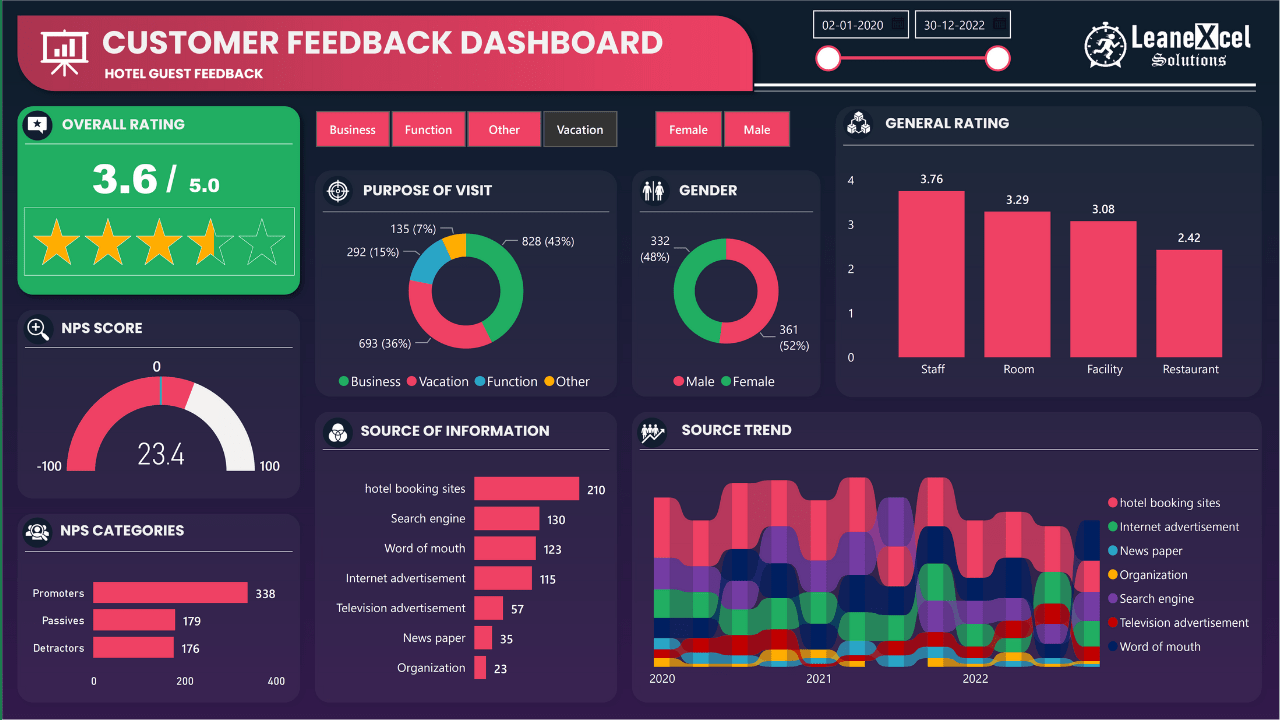



---



#🧩 2 งานของ DS

### 2.1 Load และ Clean
- Load ข้อมูล csv
- ข้อมูลมีค่า NaN : สัญลักษณ์ที่แทนการไม่มีข้อมูลใน numpy และ pandas

In [ ]:
import pandas as pd

dadf = pd.read_csv('dfmain_latlng.csv')

dadf = dadf.dropna()    # ลบค่าว่าง ค่า NaN ออก

dadf


,Unnamed: 0,customerID,name,zip,orderID,orderDate,shippedDate,productID,quantity,priceEach,state_name,lat,lng
555,601,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_3856,32.0,137.62,Puerto Rico,18.18027,-66.75266
556,602,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_4620,28.0,75.18,Puerto Rico,18.36075,-67.17541
557,603,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S32_2206,38.0,32.99,Puerto Rico,18.45744,-67.12225
560,606,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S12_4473,42.0,98.36,Puerto Rico,18.16585,-66.93716
564,610,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S18_4027,25.0,117.77,Puerto Rico,18.29110,-67.12243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,2838,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_2840,42.0,30.76,Rhode Island,41.96552,-71.47628
2685,2839,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_4048,28.0,108.82,Rhode Island,41.94330,-71.64581
2686,2840,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_1268,49.0,84.75,Rhode Island,41.47838,-71.31993
2687,2841,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_2509,27.0,51.95,Rhode Island,41.51261,-71.32522




---



# ML อย่างง่าย




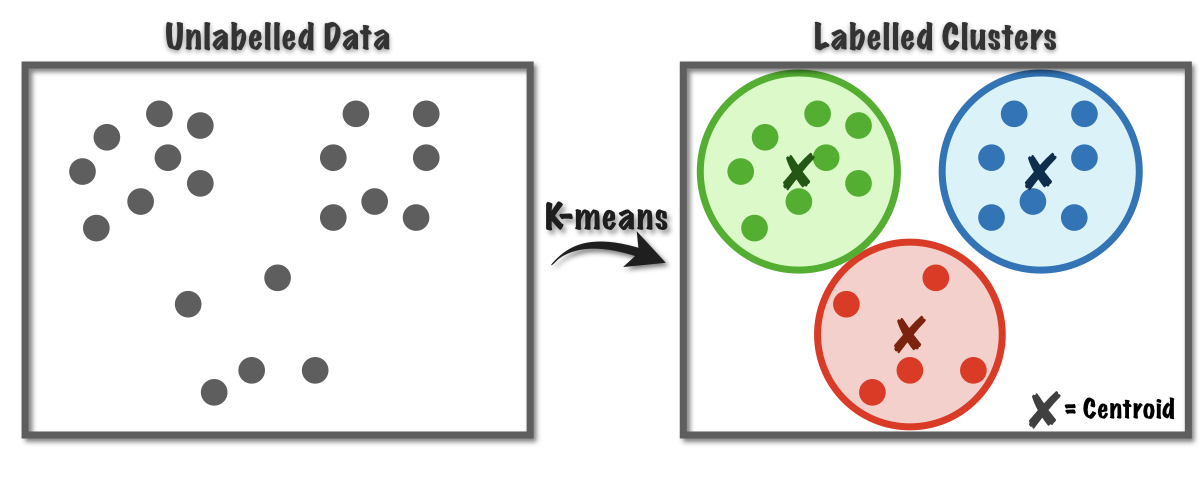

#### 2.2 Clustering

- ผู้บริหาร ให้แบ่งกลุ่มลูกค้า เพื่อจัดโปรโมชั่นช่วง ซัมเมอร์ ให้เกิดการซื้อซ้ำ
- ให้หาจำนวนกลุ่มที่เหมาะสม และรายชื่อลูกค้าในกลุ่มนั้น ๆ เพื่อทำการตลาด

In [ ]:
pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 25.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 75.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.0/165.0 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 24.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 19.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pycaret.clustering import *
mpl.rcParams['figure.dpi'] = 300

In [ ]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

dataKmean =  dadf[['quantity','priceEach']].copy()
dataKmean

,quantity,priceEach
555,32.0,137.62
556,28.0,75.18
557,38.0,32.99
560,42.0,98.36
564,25.0,117.77
...,...,...
2684,42.0,30.76
2685,28.0,108.82
2686,49.0,84.75
2687,27.0,51.95


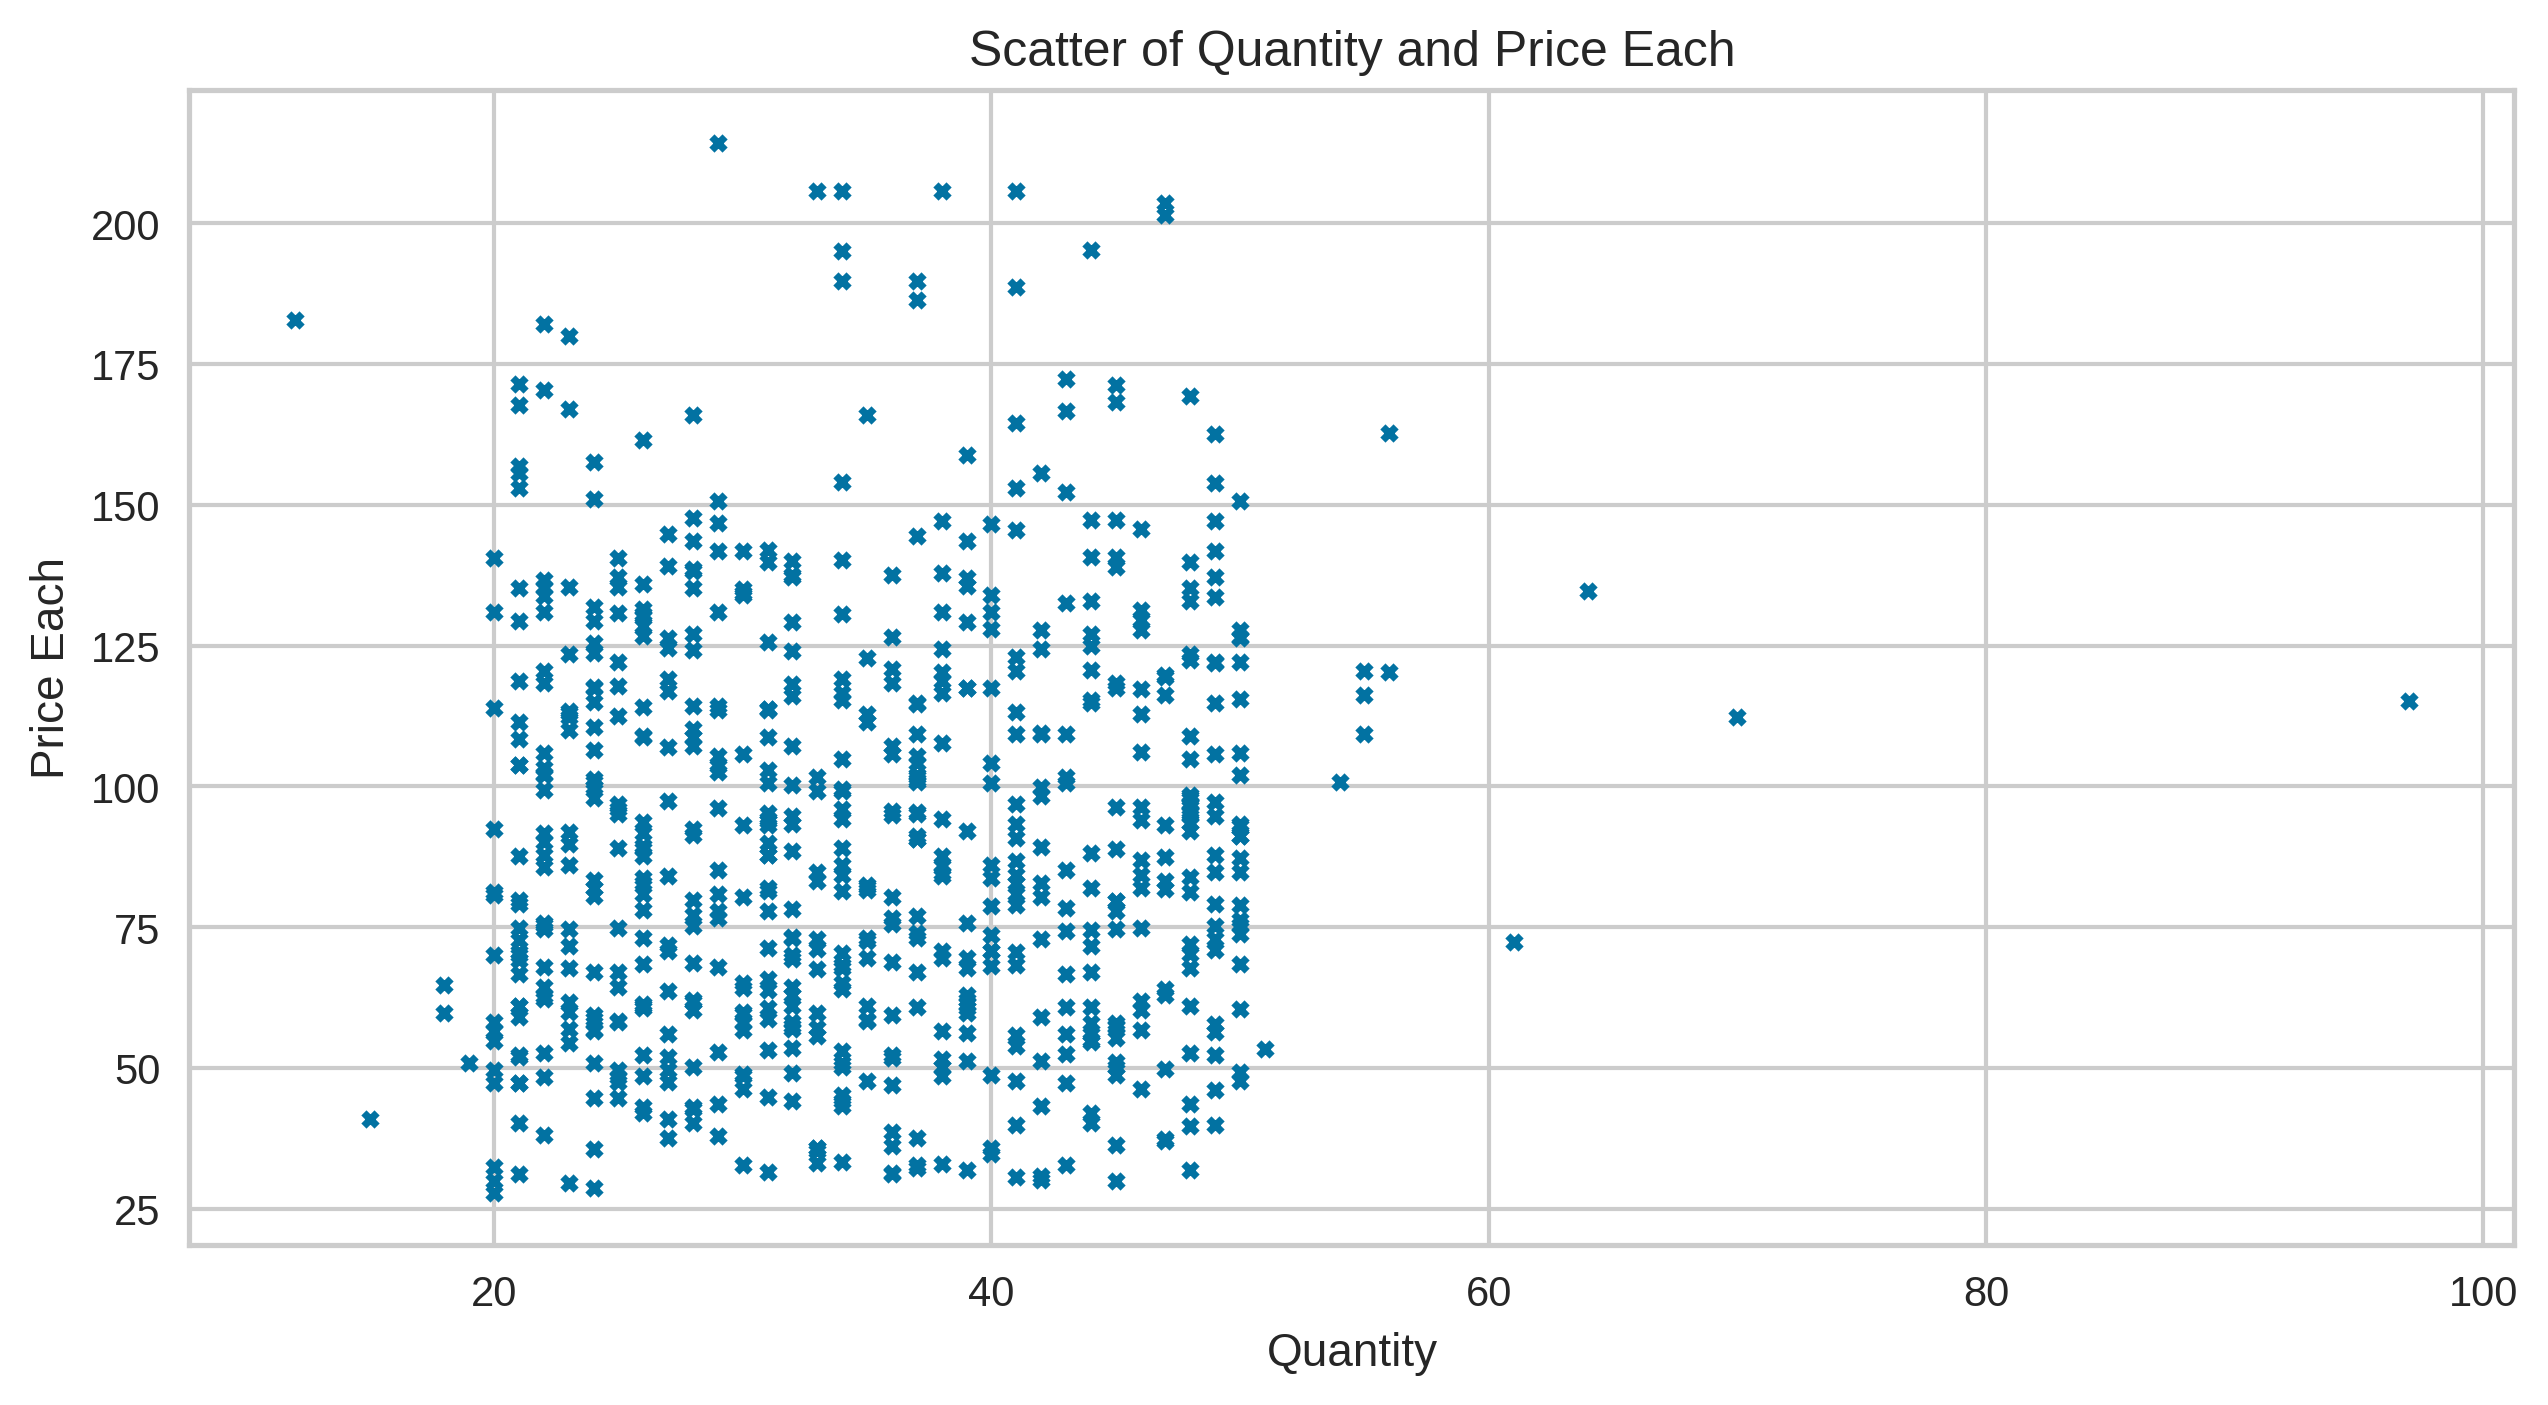

In [ ]:
# เปรียบเทียบราคาขาย และปริมาณสินค้าที่ขาย
# dadf quantity	priceEach

plt.figure(figsize=(10,5))
s=10
plt.scatter(dadf['quantity'],dadf['priceEach'],s=s,marker="x")

plt.title("Scatter of Quantity and Price Each")
plt.xlabel("Quantity")
plt.ylabel("Price Each")

plt.ticklabel_format(style='plain')
plt.show()

#### K-Mean Clustering
- ขั้นตอนที่ 1 : กำหนดจำนวนกลุ่มที่ต้องการจัดกลุ่มของข้อมูล แทนค่าด้วย K
- ขั้นตอนที่ 2 : Algorithm จะคำนวณค่าจุดศูนย์กลางของแต่ละกลุ่ม เรียกว่า Centroid
- ขั้นตอนที่ 3 : คำนวณระยะทางจากจุดข้อมูลต่างๆ กับจุดศูนย์กลาง ข้อมูลจะถูกจัดกลุ่ม (Cluster) กับจุดศูนย์กลางที่ใกล้ที่สุด
- ขั้นตอนที่ 4 : หาค่าเฉลี่ยของแต่ละกลุ่มเพื่อกำหนดจุดศูนย์กลางใหม่ แล้วทำขั้นตอนที่ 3 ซ้ำจนกว่าค่าเฉลี่ยหรือจุดศูนย์กลางไม่เปลี่ยนแปลง


##### ขั้นตอนที่ 1 :
- กำหนดจำนวนกลุ่มที่ต้องการจัดกลุ่มของข้อมูล
- หาค่า K ด้วยเทคนิค KElbowVisualizer
- ได้ค่า K ที่เหมาะสม

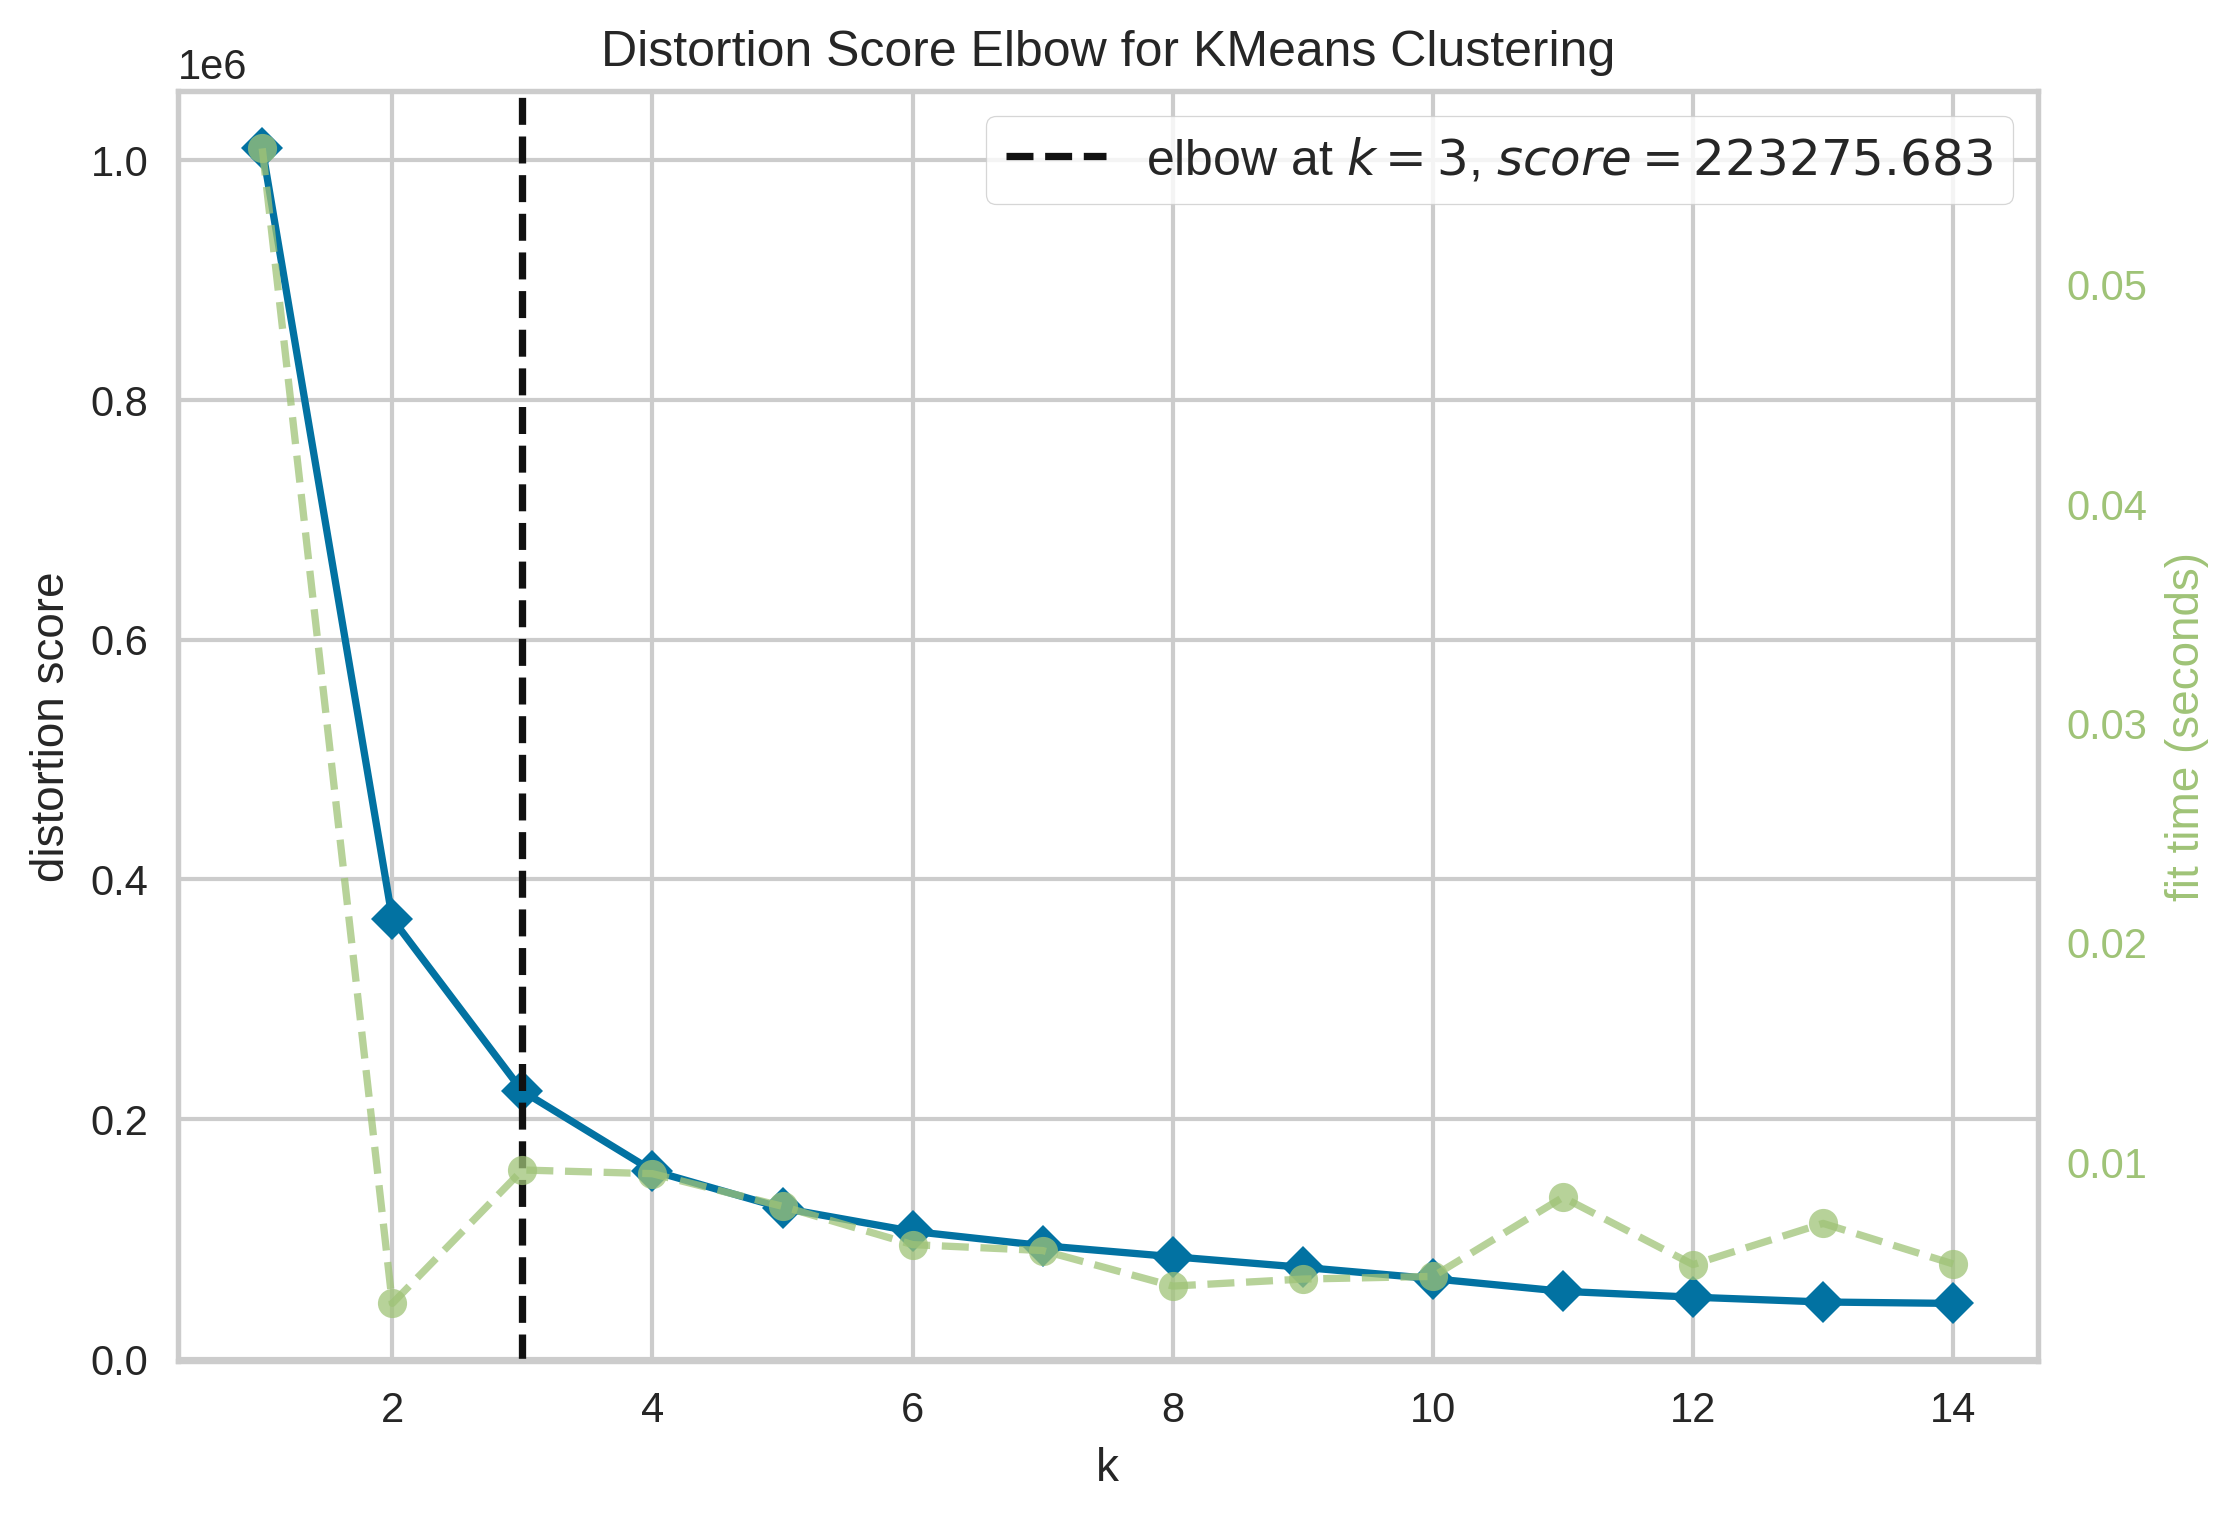

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(n_init="auto")
visualizer = KElbowVisualizer(model, k=(1,15)).fit(dataKmean)
visualizer.show()

In [ ]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
kmeans.fit(dataKmean)

identified_clusters = kmeans.fit_predict(dataKmean)
identified_clusters


array([1, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0,
       0, 0, 1, 0, 2, 0, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0,
       1, 0, 2, 0, 2, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0,
       2, 1, 2, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 0, 2, 1, 1, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 2, 2, 2, 0, 0, 2, 1, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2,
       2, 0, 1, 1, 2, 1, 0, 2, 0, 2, 2, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 1,
       1, 2, 1, 0, 0, 0, 2, 2, 2, 0, 0, 2, 1, 1, 0, 0, 1, 2, 0, 0, 0, 0,
       2, 0, 1, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 1, 2, 2, 0, 2, 2, 0, 2, 0,
       2, 2, 1, 0, 0, 2, 2, 1, 0, 0, 2, 0, 0, 2, 1, 0, 0, 2, 1, 1, 0, 2,
       2, 2, 1, 0, 1, 2, 2, 0, 0, 0, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0,
       2, 2, 2, 0, 0, 1, 2, 0, 2, 1, 0, 2, 1, 0, 1, 2, 0, 0, 2, 1, 2, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 0,
       0, 0, 2, 2, 2, 0, 2, 0, 1, 1, 2, 2, 0, 2, 2, 2, 0, 1, 1, 2, 1, 2,
       2, 1, 1, 0, 2, 0, 0, 0, 0, 2, 0, 1, 2, 2, 0,

In [ ]:
data_with_clusters = dataKmean.copy()

data_with_clusters['customerID'] = dadf['customerID'] # เติมข้อมูล ID
data_with_clusters['Clusters'] = identified_clusters  # เติมข้อมูล กลุ่ม

data_with_clusters.head(5)

,quantity,priceEach,customerID,Clusters
555,32.0,137.62,141,1
556,28.0,75.18,141,0
557,38.0,32.99,141,0
560,42.0,98.36,141,2
564,25.0,117.77,141,2


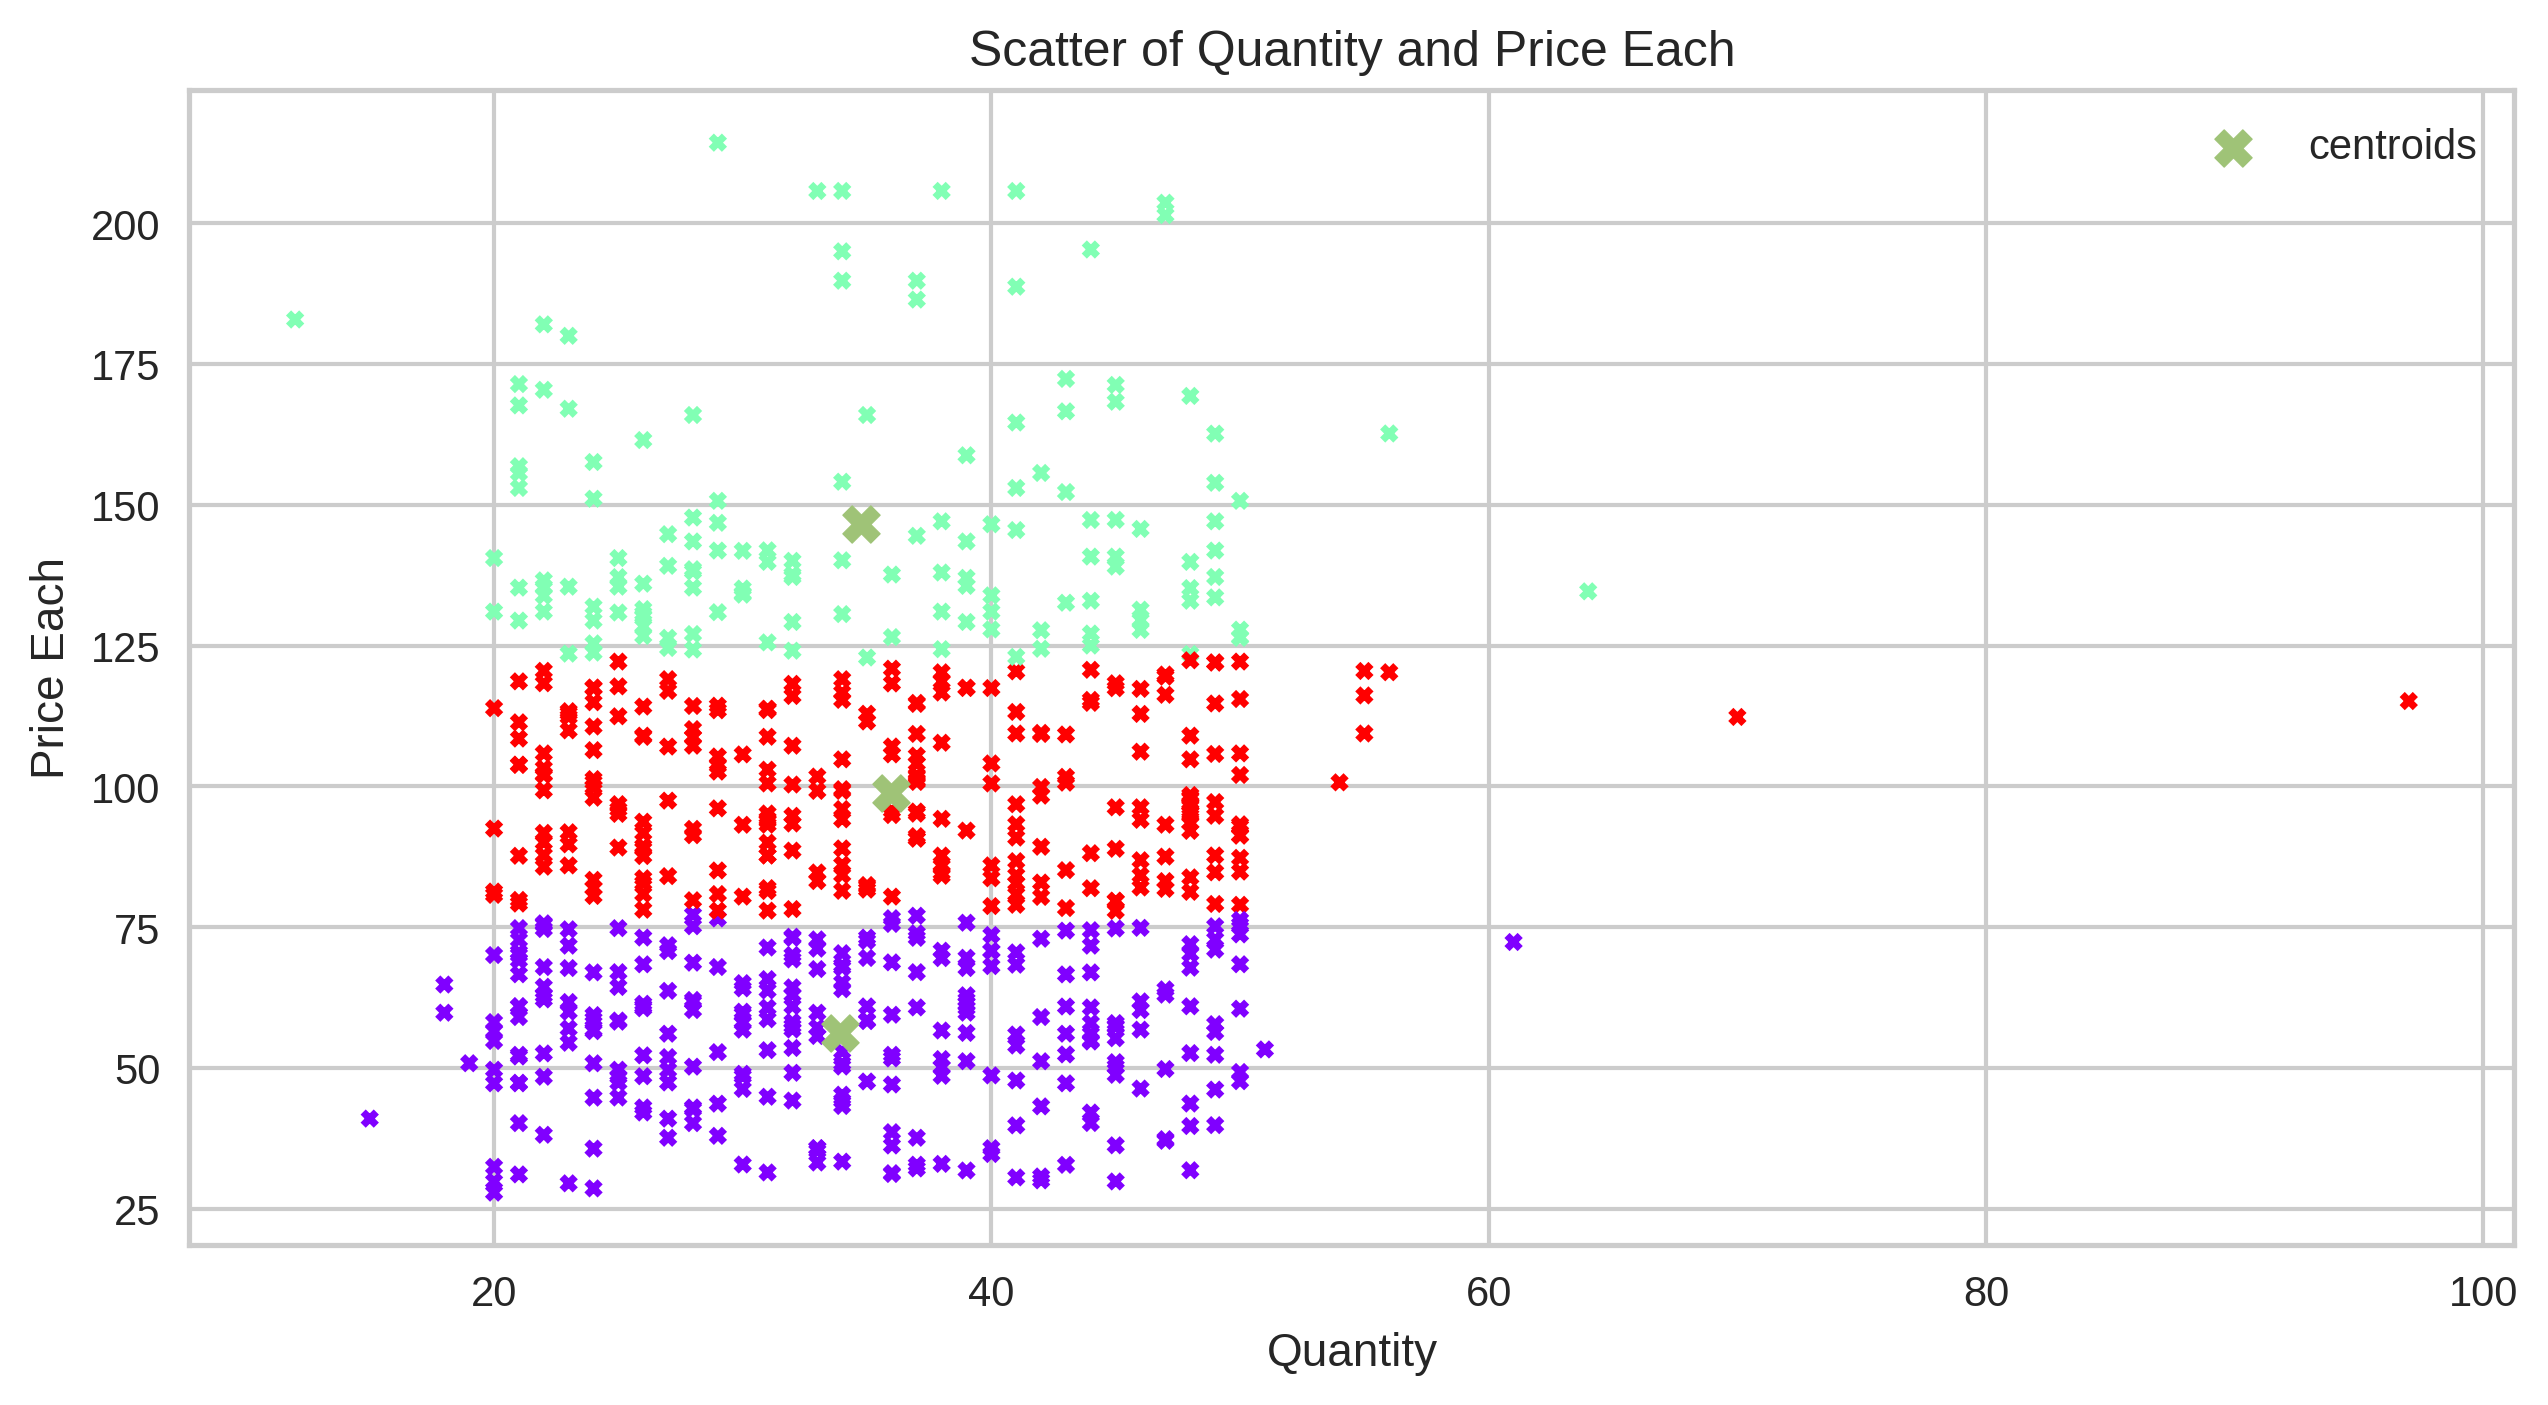

In [ ]:
plt.figure(figsize=(10,5))
s=10


plt.scatter(dataKmean['quantity'],dataKmean['priceEach'],s=s,c=data_with_clusters['Clusters'],cmap='rainbow',marker="x")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            marker="X", c="g", s=80, label="centroids")
plt.title("Scatter of Quantity and Price Each")
plt.xlabel("Quantity")
plt.ylabel("Price Each")


plt.legend()
plt.ticklabel_format(style='plain')
plt.show()

In [ ]:
dfx = data_with_clusters.loc[data_with_clusters['Clusters'] == 2]  #สมาชิกกลุ่ม
dfx

,quantity,priceEach,customerID,Clusters
560,42.0,98.36,141,2
564,25.0,117.77,141,2
570,41.0,82.83,141,2
577,49.0,122.02,141,2
581,41.0,80.84,141,2
...,...,...,...,...
2675,34.0,95.99,495,2
2677,43.0,109.23,495,2
2681,47.0,119.87,495,2
2685,28.0,108.82,495,2


##### ผลที่ได้
- จากข้อมูลตัวอย่างพฤติกรรมการซื้อสินค้า จัดกลุ่มลูกค้าออกเป็น 3 กลุ่ม
- วิเคราะห์ต่อได้ว่าลูกค้าแต่ละกลุ่ม แต่ละรัฐ มีพฤติกรรมการซื้อสินค้าอย่างไร และนำไปใช้ในการจัดโปรโมชั่นหรือวางกลยุทธ์การขายสินค้าให้ตรงกับลูกค้าได้มากขึ้น

#### 2.3 Regression

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
dfx.head(5)

,quantity,priceEach,customerID,Clusters
560,42.0,98.36,141,2
564,25.0,117.77,141,2
570,41.0,82.83,141,2
577,49.0,122.02,141,2
581,41.0,80.84,141,2


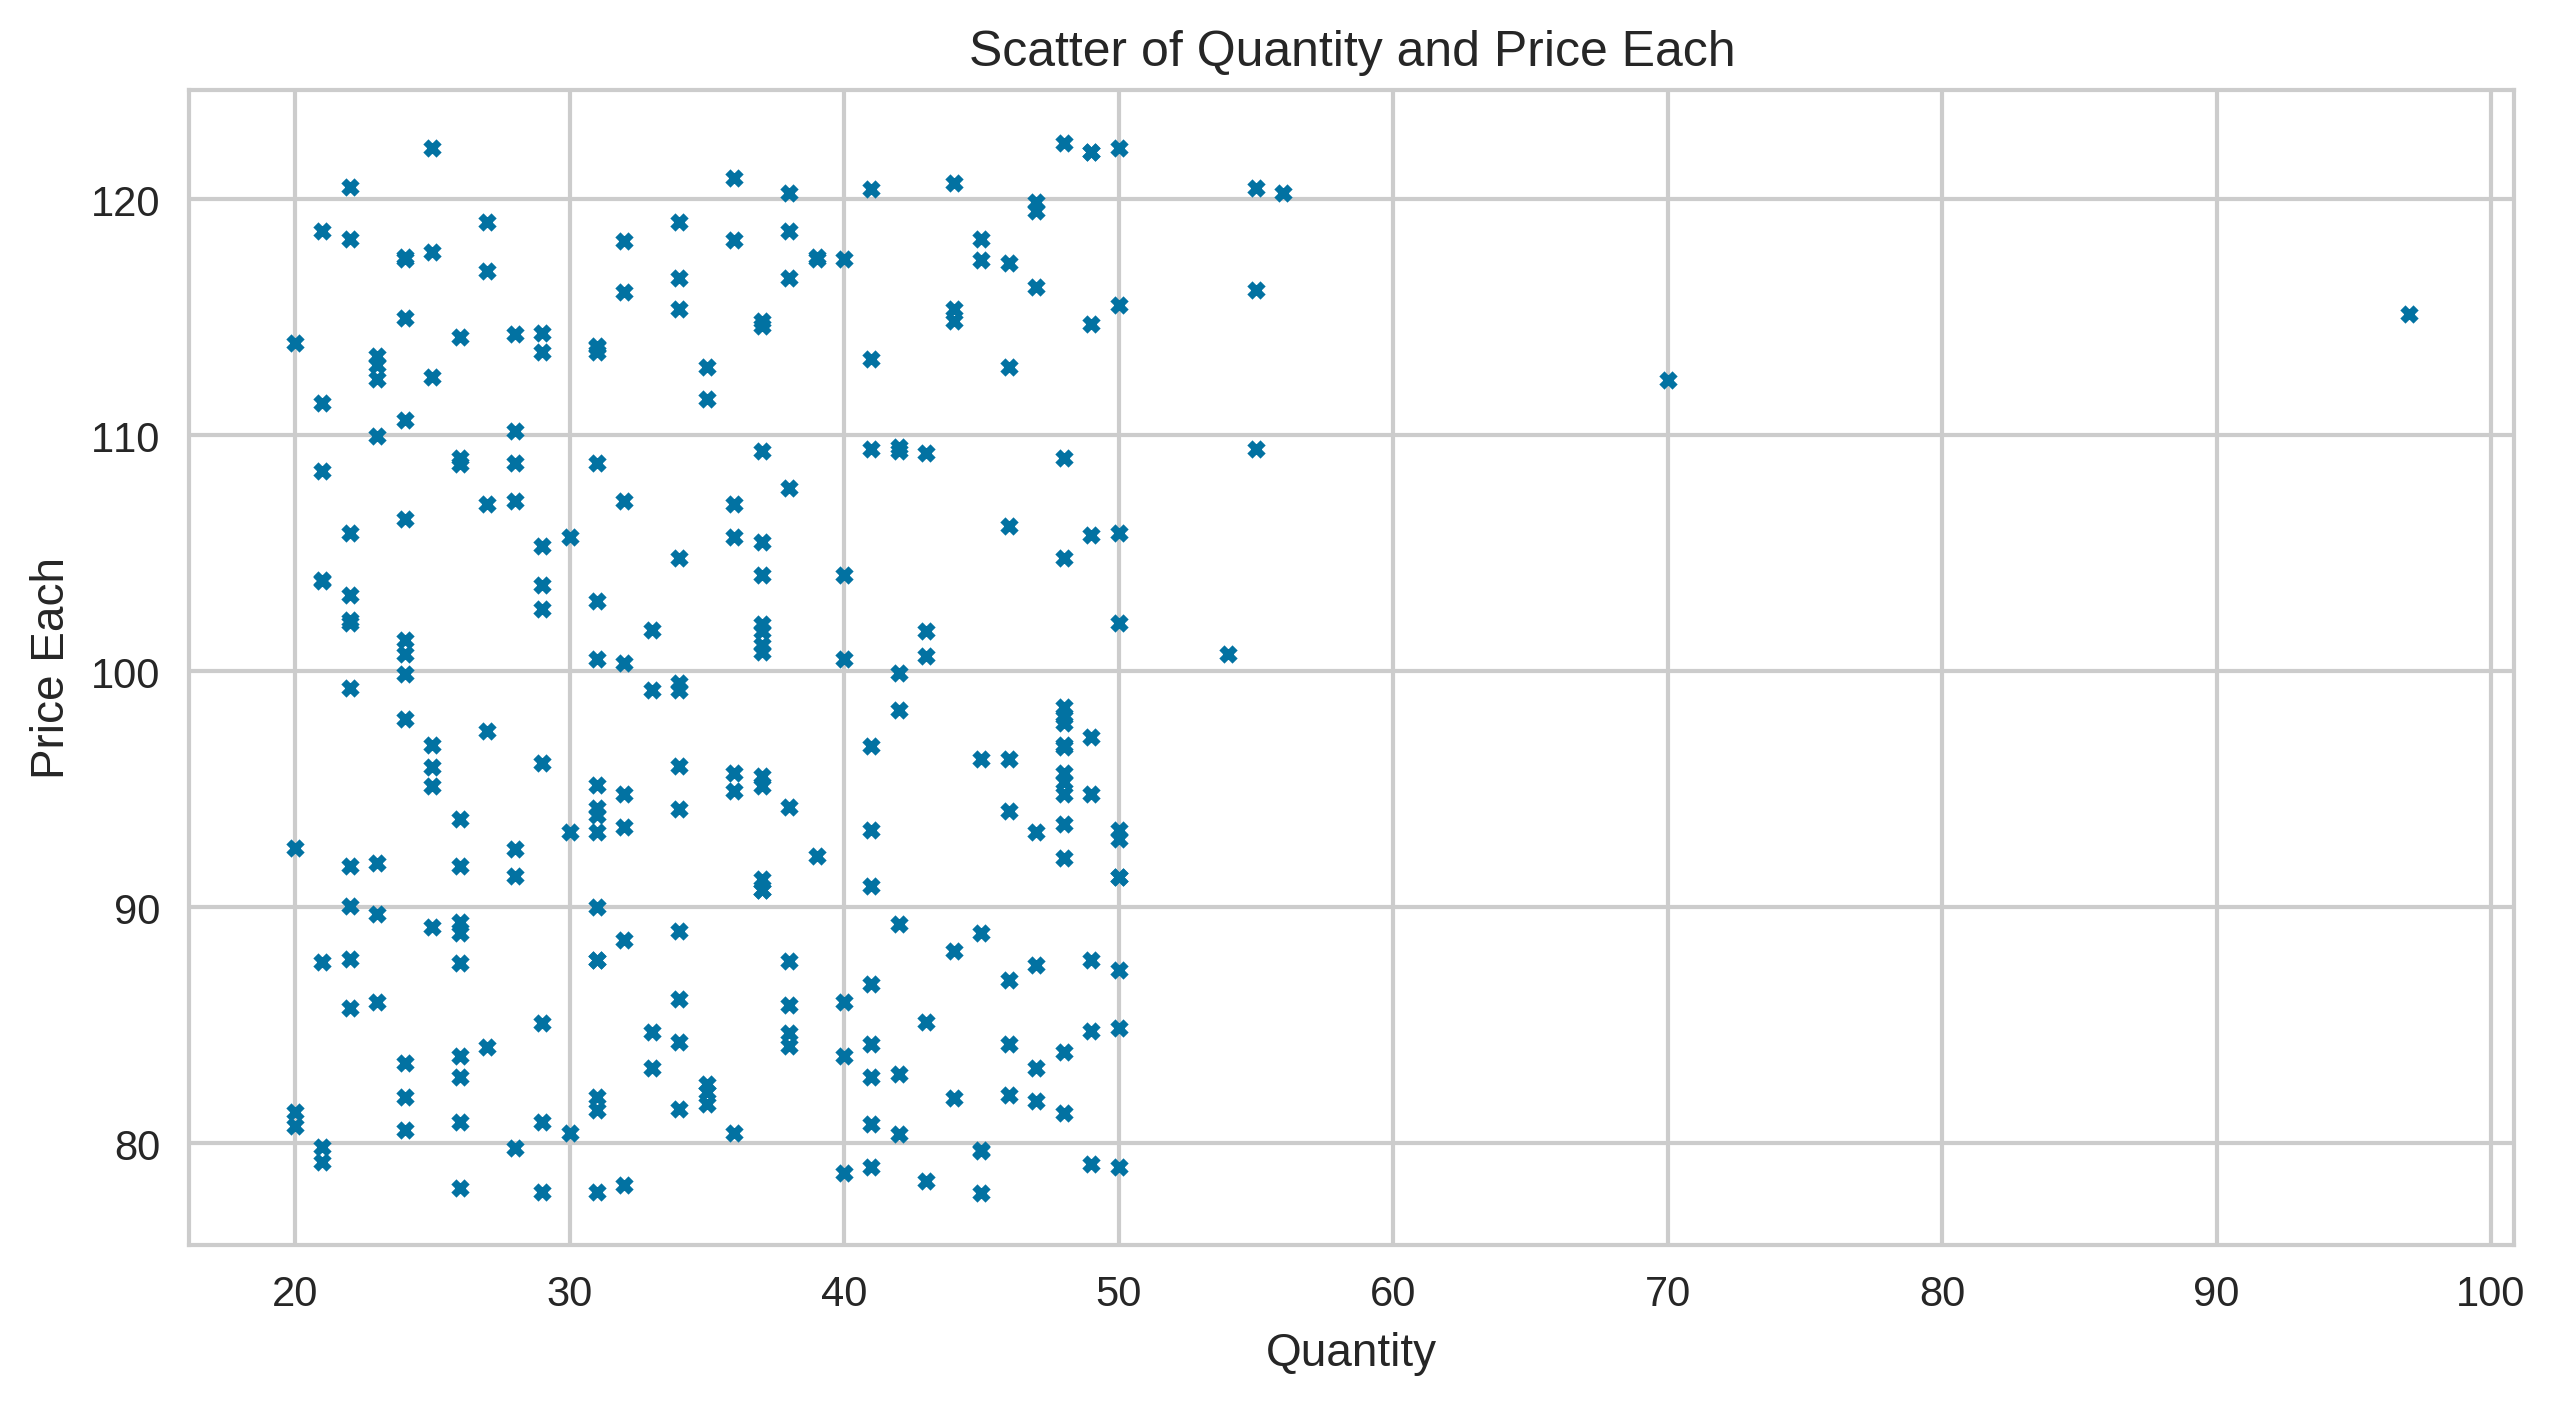

In [ ]:
# วิเคราะห์ราคาขาย และปริมาณสินค้าที่ขาย

plt.figure(figsize=(10,5))
s=10
plt.scatter(dfx['quantity'],dfx['priceEach'],s=s,marker="x")

plt.title("Scatter of Quantity and Price Each")
plt.xlabel("Quantity")
plt.ylabel("Price Each")

plt.ticklabel_format(style='plain')
plt.show()

In [ ]:
X = np.array(dfx['quantity']).reshape(-1, 1)
y = np.array(dfx['priceEach']).reshape(-1, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [ ]:
regr = LinearRegression()

regr.fit(X_train, y_train)  # สอนกันล่ะ

print(regr.score(X_test, y_test))

0.00616092141665503


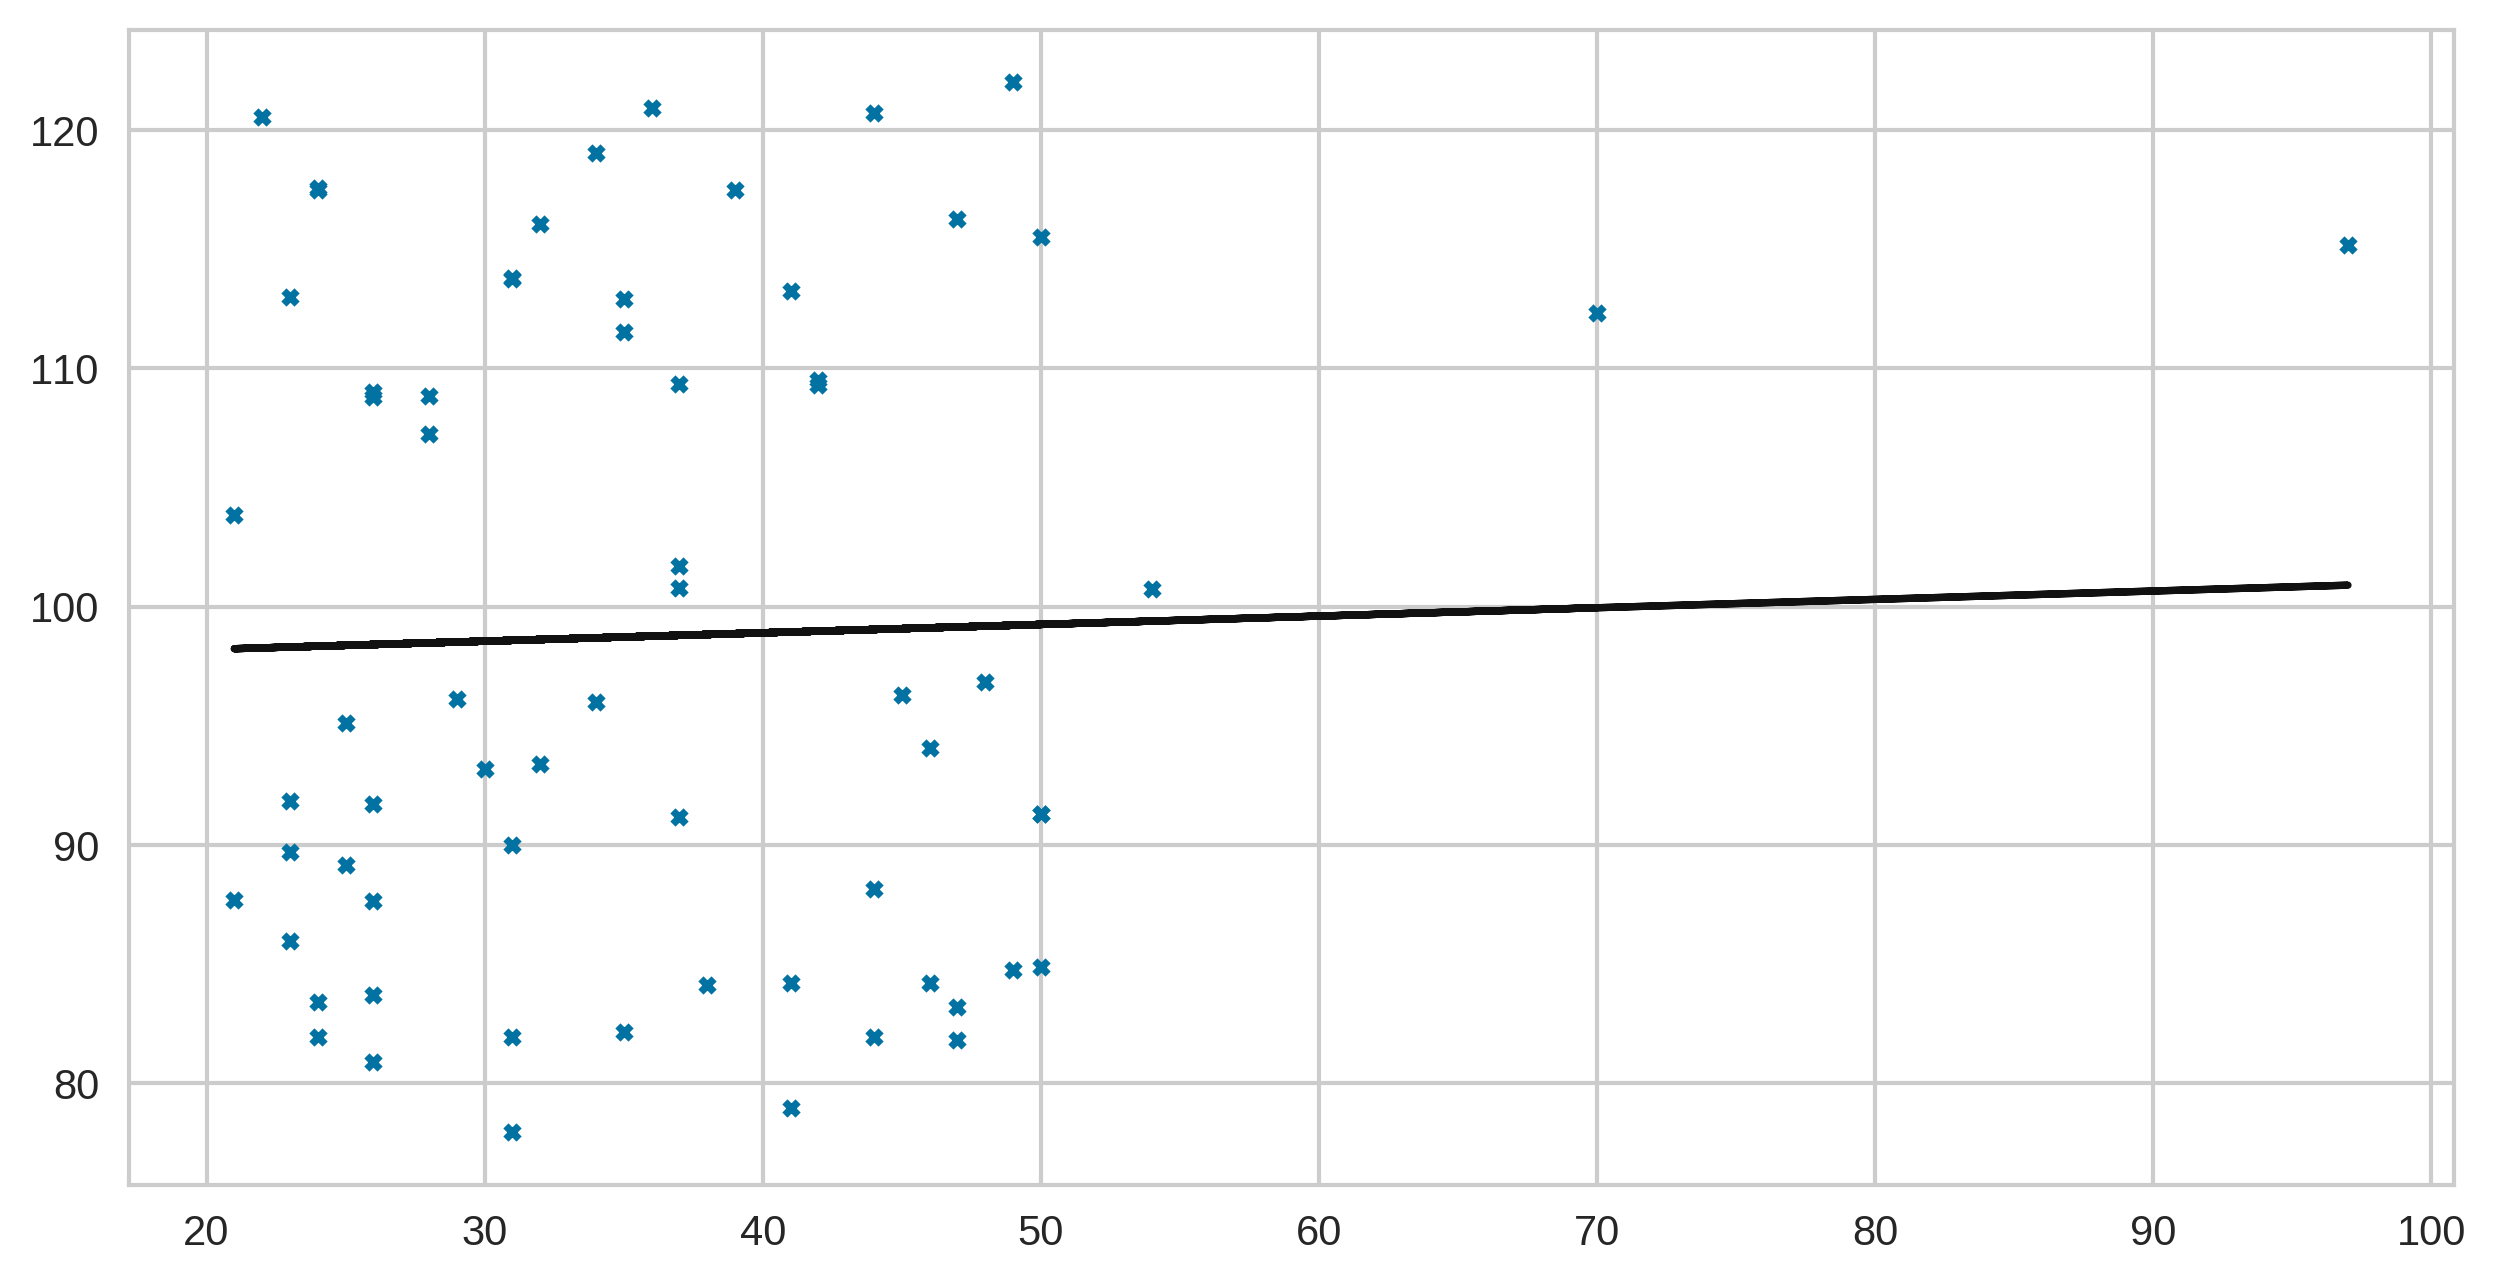

In [ ]:
# Data scatter of predicted values

plt.figure(figsize=(10,5))
s=10

y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color ='b',s=s,marker="x")
plt.plot(X_test, y_pred, color ='k')

plt.ticklabel_format(style='plain')
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True
rmse = mean_squared_error(y_true=y_test,y_pred=y_pred,squared=False)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)

MAE: 12.285113342331663
MSE: 183.92121365755494
RMSE: 13.561755552197324




---



#### 2.3 Tree

In [ ]:
dfml = dadf.copy()

dfml

,Unnamed: 0,customerID,name,zip,orderID,orderDate,shippedDate,productID,quantity,priceEach,state_name,lat,lng
555,601,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_3856,32.0,137.62,Puerto Rico,18.18027,-66.75266
556,602,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_4620,28.0,75.18,Puerto Rico,18.36075,-67.17541
557,603,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S32_2206,38.0,32.99,Puerto Rico,18.45744,-67.12225
560,606,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S12_4473,42.0,98.36,Puerto Rico,18.16585,-66.93716
564,610,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S18_4027,25.0,117.77,Puerto Rico,18.29110,-67.12243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,2838,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_2840,42.0,30.76,Rhode Island,41.96552,-71.47628
2685,2839,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_4048,28.0,108.82,Rhode Island,41.94330,-71.64581
2686,2840,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_1268,49.0,84.75,Rhode Island,41.47838,-71.31993
2687,2841,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_2509,27.0,51.95,Rhode Island,41.51261,-71.32522


In [ ]:
dfml.shape

(678, 13)

##### สมมติ
- มีการนำข้อมูลไปให้ผู้เชี่ยวชาญ ตัดสินใจว่า จะทำ Pro กับลูกค้าแต่ละท่านแล้ว บางส่วน
- ให้พยากรณ์บางส่วน โดยอ้างอิงข้อมูลจากที่ผู้เชี่ยวชาญ ได้ทำไว้

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# ปรับปรุงข้อมูลจาก /content/dfmain_latlng.csv
# เติมข้อมูล Pro ด้วยการสุ่ม dfml['Pro'] = np.random.choice([0, 1], size=len(dfml))
# dfml.to_csv('dfml.csv')

dfml = pd.read_csv('dfml.csv')

dfml

,Unnamed: 0.1,Unnamed: 0,customerID,name,zip,orderID,orderDate,shippedDate,productID,quantity,priceEach,state_name,lat,lng,Pro
0,555,601,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_3856,32.0,137.62,Puerto Rico,18.18027,-66.75266,1
1,556,602,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S24_4620,28.0,75.18,Puerto Rico,18.36075,-67.17541,1
2,557,603,141,Diego Freyre,28034,10355.0,2004-12-07,2004-12-13,S32_2206,38.0,32.99,Puerto Rico,18.45744,-67.12225,1
3,560,606,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S12_4473,42.0,98.36,Puerto Rico,18.16585,-66.93716,1
4,564,610,141,Diego Freyre,28034,10358.0,2004-12-10,2004-12-16,S18_4027,25.0,117.77,Puerto Rico,18.29110,-67.12243,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,2684,2838,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_2840,42.0,30.76,Rhode Island,41.96552,-71.47628,1
674,2685,2839,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S24_4048,28.0,108.82,Rhode Island,41.94330,-71.64581,1
675,2686,2840,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_1268,49.0,84.75,Rhode Island,41.47838,-71.31993,0
676,2687,2841,495,Valarie Franco,51003,10207.0,2003-12-09,2003-12-11,S32_2509,27.0,51.95,Rhode Island,41.51261,-71.32522,0


In [ ]:
dfml[['quantity','priceEach','state_name','Pro']]

,quantity,priceEach,state_name,Pro
0,32.0,137.62,Puerto Rico,1
1,28.0,75.18,Puerto Rico,1
2,38.0,32.99,Puerto Rico,1
3,42.0,98.36,Puerto Rico,1
4,25.0,117.77,Puerto Rico,1
...,...,...,...,...
673,42.0,30.76,Rhode Island,1
674,28.0,108.82,Rhode Island,1
675,49.0,84.75,Rhode Island,0
676,27.0,51.95,Rhode Island,0


สร้างโมเดลด้วยไลบรารี่ Pycaret

In [ ]:
!pip install pycaret

In [ ]:
#X= df['Head Size(cm^3)']
#y=df['Brain Weight(grams)']
#dfml[['quantity','priceEach','state_name','Pro']]

df = dfml[['quantity','priceEach','state_name','Pro']]
X = df.drop('Pro', axis=1)
y = df['Pro']

In [ ]:
# using the train test split function
from sklearn.model_selection import train_test_split

train, test = train_test_split(df,
                                   random_state=0,
                                   test_size=0.25,
                                   shuffle=True)

In [ ]:
from pycaret.classification import *
clf1 = setup(train, target = 'Pro', session_id=786) # เรียกใชั API

,Description,Value
0,Session id,786
1,Target,Pro
2,Target type,Binary
3,Original data shape,"(508, 4)"
4,Transformed data shape,"(508, 7)"
5,Transformed train set shape,"(355, 7)"
6,Transformed test set shape,"(153, 7)"
7,Numeric features,2
8,Categorical features,1
9,Preprocess,True


In [ ]:
# compare_models()

best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.5413,0.5300,0.5520,0.5620,0.5506,0.0831,0.0845,0.1160
et,Extra Trees Classifier,0.5376,0.5197,0.5602,0.5590,0.5567,0.0720,0.0732,0.2400
dummy,Dummy Classifier,0.5267,0.5000,1.0000,0.5267,0.6900,0.0000,0.0000,0.1420
dt,Decision Tree Classifier,0.5163,0.5157,0.5196,0.5362,0.5242,0.0318,0.0291,0.0770
lightgbm,Light Gradient Boosting Machine,0.5129,0.5496,0.5307,0.5354,0.5222,0.0260,0.0267,0.4260
lr,Logistic Regression,0.5120,0.4899,0.6553,0.5247,0.5785,0.0084,0.0161,0.9370
lda,Linear Discriminant Analysis,0.5120,0.4892,0.6500,0.5256,0.5774,0.0088,0.0135,0.0780
rf,Random Forest Classifier,0.5101,0.5152,0.5518,0.5316,0.5378,0.0169,0.0159,0.3370
ridge,Ridge Classifier,0.5092,0.4892,0.6500,0.5234,0.5759,0.0029,0.0079,0.0760
svm,SVM - Linear Kernel,0.5015,0.4825,0.3865,0.2752,0.3065,0.0190,0.0318,0.0770


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
# สร้างโมเดล ที่ดีที่สุด

xg = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5278,0.5728,0.4737,0.5625,0.5143,0.0613,0.0622
1,0.3889,0.3452,0.4211,0.4211,0.4211,-0.2260,-0.2260
2,0.4722,0.5387,0.3684,0.5000,0.4242,-0.0427,-0.0444
3,0.4722,0.4118,0.6316,0.5000,0.5581,-0.0755,-0.0787
4,0.6944,0.6409,0.8421,0.6667,0.7442,0.3774,0.3934
5,0.4857,0.4375,0.3158,0.5455,0.4000,0.0032,0.0035
6,0.5429,0.6151,0.5789,0.5789,0.5789,0.0789,0.0789
7,0.5714,0.4869,0.6111,0.5789,0.5946,0.1408,0.1410
8,0.7429,0.8268,0.7778,0.7368,0.7568,0.4845,0.4852


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# save pipeline
save_model(xg, 'my_tuned_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['quantity', 'priceEach'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=['state_name'],
                                     trans...
                                importance_type=None,
                                interaction_constraints=None, learning_rate=None,
      

In [ ]:
# load pipeline
from pycaret.regression import load_model

#loaded_tuned_pipeline = load_model('my_tuned_pipeline')
#loaded_tuned_pipeline

load_xg = load_model('my_tuned_pipeline')  # .pkl


Transformation Pipeline and Model Successfully Loaded


In [ ]:
predictions = predict_model(load_xg, data = test)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4941,0.4701,0.5181,0.4831,0.5000,-0.0106,-0.0107


,quantity,priceEach,state_name,Pro,prediction_label,prediction_score
279,31.0,81.430000,Massachusetts,1,0,0.6255
144,41.0,164.610001,Massachusetts,0,0,0.6137
441,50.0,91.290001,Massachusetts,0,1,0.8953
390,22.0,75.699997,Massachusetts,0,0,0.9521
589,50.0,84.879997,Massachusetts,1,1,0.9167


In [ ]:
evaluate_model(load_xg)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

for column in test:
    if test[column].dtype.kind == 'O':
        test[column]= label_encoder.fit_transform(test[column])
        test[column]= label_encoder.fit_transform(test[column])

In [ ]:
test

,quantity,priceEach,state_name,Pro
279,31.0,81.43,0,1
144,41.0,164.61,0,0
441,50.0,91.29,0,0
390,22.0,75.70,0,0
589,50.0,84.88,0,1
...,...,...,...,...
92,25.0,135.47,1,1
436,40.0,70.81,0,1
66,43.0,85.14,1,0
456,39.0,51.22,0,1


<Figure size 2400x1650 with 0 Axes>

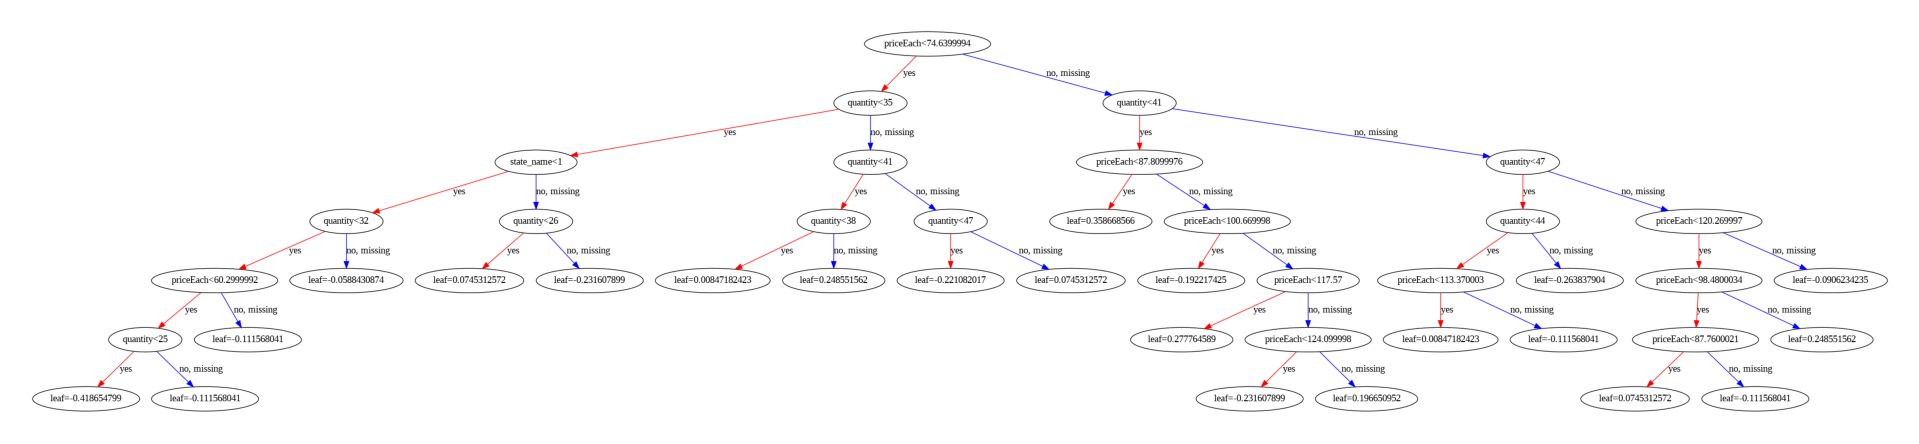

In [ ]:
# plot decision tree
from numpy import loadtxt
from xgboost import XGBClassifier
from xgboost import plot_tree
import matplotlib.pyplot as plt

# load data
dataset = test

# encode

# split data into X and y
X = dataset.iloc[:,0:3]
y = dataset.iloc[:,3]

# fit model no training data
model = XGBClassifier()
model.fit(X, y)

# plot single tree
plt.figure()
plot_tree(model)
plt.show()



---



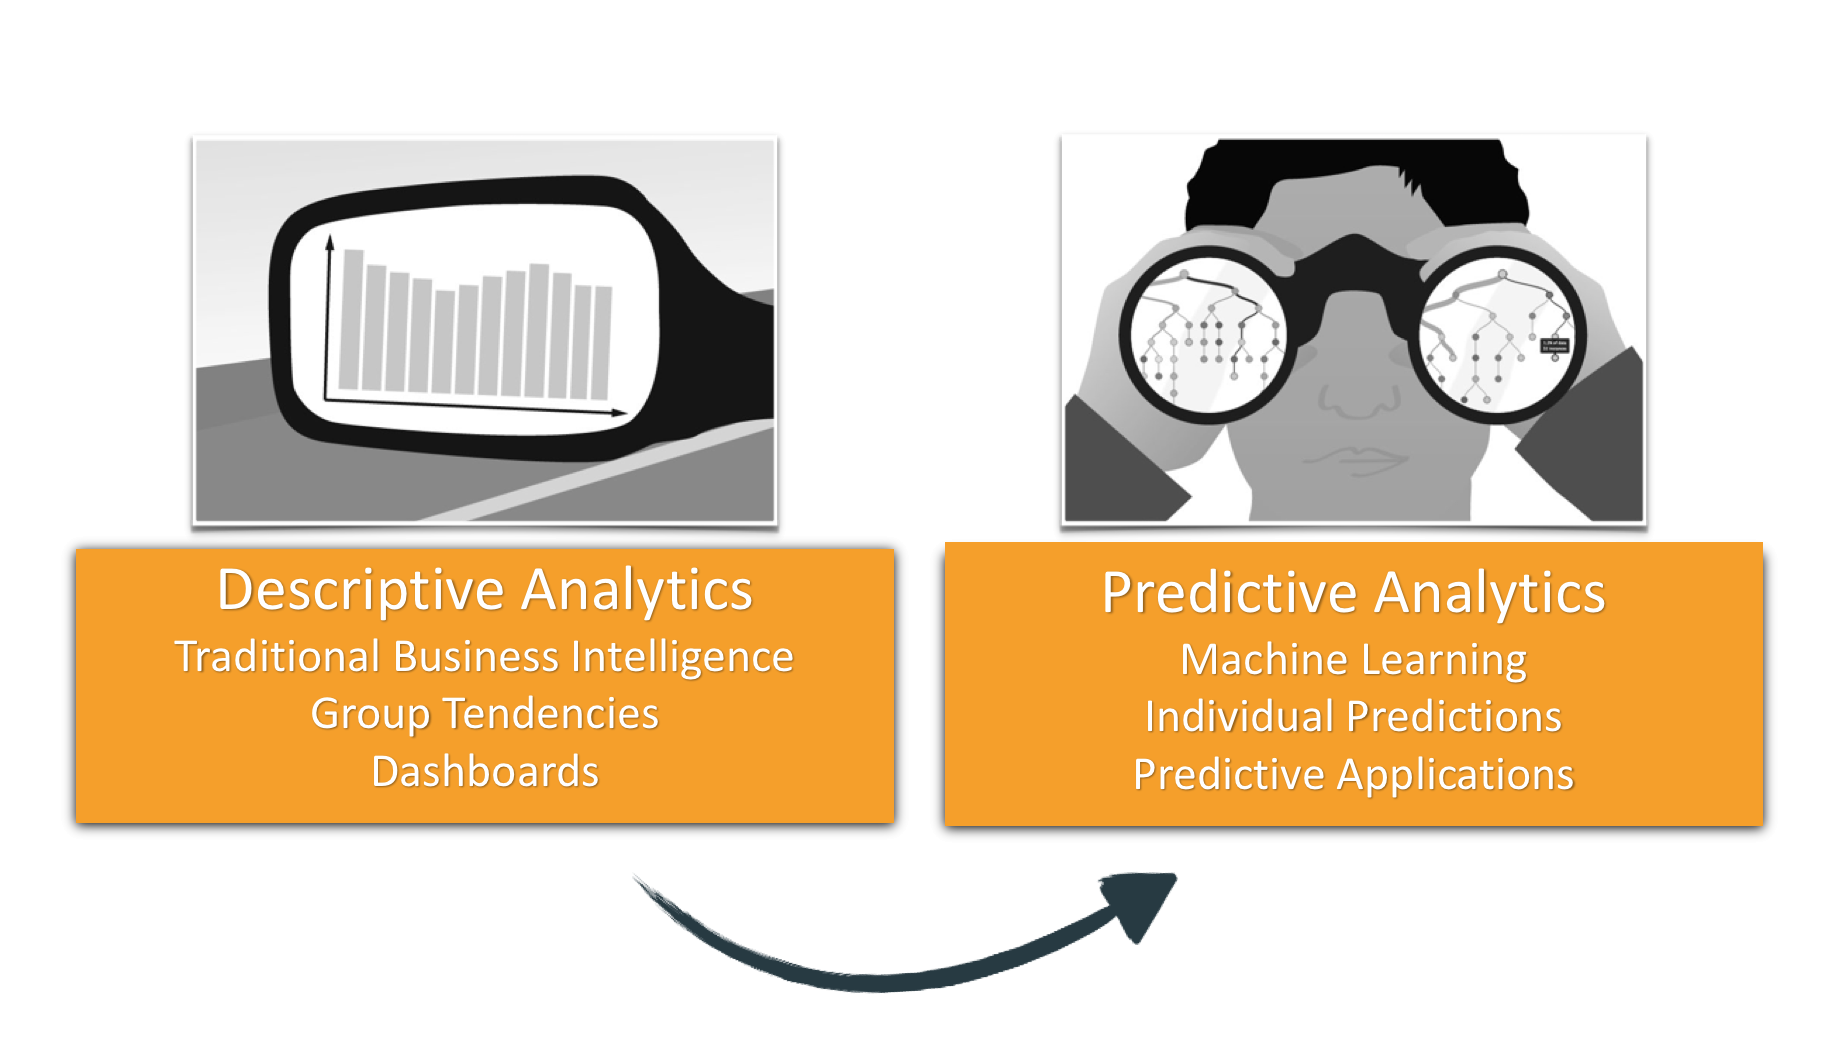

# END